# 🎯 Módulo 5: Classificação
## Objetivos de Aprendizagem
- Implementar Regressão Logística e interpretar odds ratios
- Visualizar a função sigmoide e fronteiras de decisão
- Treinar Árvores de Decisão e comparar profundidades
- Implementar KNN e comparar diferentes valores de K
- Aplicar classificação multiclasse (OvO e OvA)

## 2. Teoria e Equações

### 2.1 Regressão Logística — Função Sigmoide
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

### 2.2 Interpretação via Odds Ratio
$$\text{Odds} = \frac{P(\text{evento})}{1-P(\text{evento})} = e^z$$
$$\text{Odds Ratio para } x_j: \quad OR_j = e^{\beta_j}$$
- $OR > 1$: aumenta a chance do evento
- $OR < 1$: diminui a chance do evento

### 2.3 Log-Verossimilhança (função de custo)
$$\ell(\beta) = \sum_{i=1}^n \left[y_i \log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right]$$

### 2.4 Árvore de Decisão — Impureza de Gini
$$Gini(t) = 1 - \sum_{k=1}^K p_{tk}^2$$
O melhor split maximiza o **ganho de Gini** (redução de impureza).

### 2.5 Entropia (Information Gain)
$$H(t) = -\sum_{k=1}^K p_{tk}\log_2(p_{tk})$$
$$IG = H(\text{pai}) - \sum_j \frac{|N_j|}{|N|}H(\text{filho}_j)$$

### 2.6 KNN — Distância Euclidiana
$$d(x, x') = \sqrt{\sum_{j=1}^p (x_j - x'_j)^2}$$
Classificação: voto majoritário entre os K vizinhos mais próximos.

### 2.7 Multiclasse
| Estratégia | Descrição | Nº de Modelos |
|------------|-----------|---------------|
| OvO (One vs One) | Um modelo para cada par | $\binom{K}{2}$ |
| OvA (One vs All) | Um modelo por classe | $K$ |

📊 DATASET: Churn de Clientes Telecom

Shape: (700, 6) | Taxa de churn: 14.7%

🔢 Coeficientes e Odds Ratios:


,Feature,Coeficiente,Odds Ratio,Interpretação
2,valor_mensal,0.623,1.864,Aumenta risco
3,calls_suporte,0.117,1.124,Aumenta risco
1,num_servicos,-0.192,0.825,Diminui risco
0,meses_contrato,-0.306,0.737,Diminui risco
4,satisfacao,-0.694,0.500,Diminui risco



AUC-ROC: 0.5947


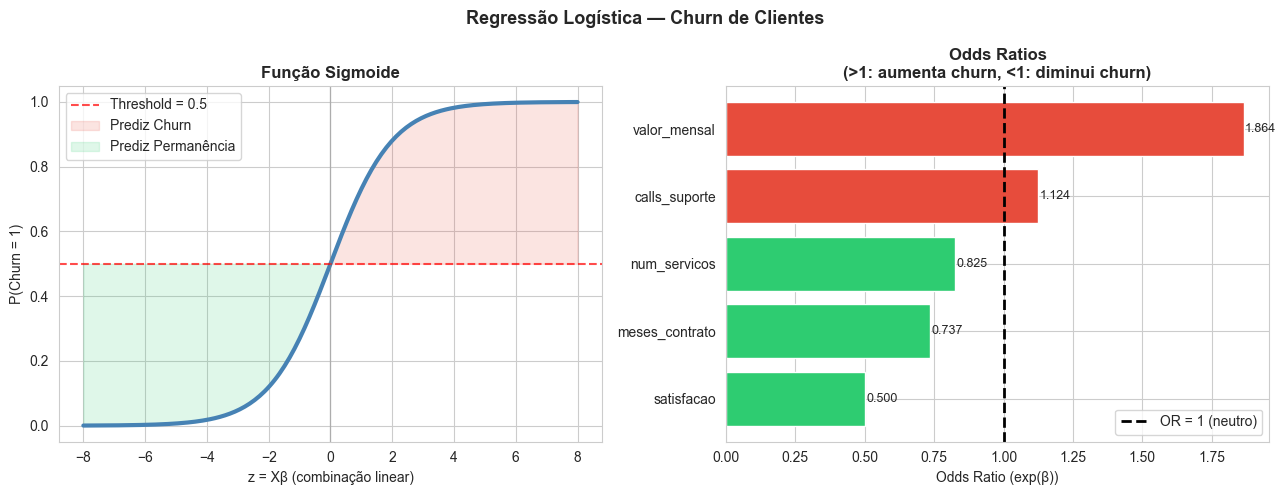

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")

# Dataset: Churn de Clientes Telecom
n = 700
meses_contrato = np.random.randint(1, 60, n)
num_servicos = np.random.randint(1, 6, n)
valor_mensal = np.random.normal(80, 25, n).clip(20, 200)
calls_suporte = np.random.poisson(1.5, n).clip(0, 10)
satisfacao = np.random.randint(1, 11, n)

# Probabilidade de churn
logit = (-2.0 + 0.05*calls_suporte - 0.01*meses_contrato + 
         0.02*valor_mensal - 0.15*satisfacao - 0.1*num_servicos)
prob_churn = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, prob_churn)

df = pd.DataFrame({
    'meses_contrato': meses_contrato,
    'num_servicos': num_servicos,
    'valor_mensal': valor_mensal,
    'calls_suporte': calls_suporte,
    'satisfacao': satisfacao,
    'churn': churn
})

X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("=" * 55)
print("📊 DATASET: Churn de Clientes Telecom")
print("=" * 55)
print(f"\nShape: {df.shape} | Taxa de churn: {y.mean():.1%}")

# Regressão Logística
lr = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(random_state=42))])
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

# Coeficientes e Odds Ratios
coefs = lr.named_steps['lr'].coef_[0]
scaler_std = lr.named_steps['sc'].scale_
odds_ratios = np.exp(coefs)

print("\n🔢 Coeficientes e Odds Ratios:")
or_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': coefs.round(3),
    'Odds Ratio': odds_ratios.round(3),
    'Interpretação': ['Aumenta risco' if v > 1 else 'Diminui risco' for v in odds_ratios]
}).sort_values('Odds Ratio', ascending=False)
display(or_df)
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Sigmoide + Odds Ratio plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regressão Logística — Churn de Clientes', fontsize=13, fontweight='bold')

z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))
axes[0].plot(z, sigma, 'steelblue', lw=3)
axes[0].axhline(0.5, color='red', lw=1.5, linestyle='--', alpha=0.7, label='Threshold = 0.5')
axes[0].axvline(0, color='gray', lw=1, linestyle='-', alpha=0.4)
axes[0].fill_between(z, sigma, 0.5, where=(sigma > 0.5), alpha=0.15, color='#e74c3c', label='Prediz Churn')
axes[0].fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.15, color='#2ecc71', label='Prediz Permanência')
axes[0].set_xlabel('z = Xβ (combinação linear)'); axes[0].set_ylabel('P(Churn = 1)')
axes[0].set_title('Função Sigmoide', fontweight='bold'); axes[0].legend()

or_sorted = or_df.sort_values('Odds Ratio')
cores_or = ['#e74c3c' if v > 1 else '#2ecc71' for v in or_sorted['Odds Ratio']]
bars = axes[1].barh(or_sorted['Feature'], or_sorted['Odds Ratio'], color=cores_or, edgecolor='white')
axes[1].axvline(1, color='black', lw=2, linestyle='--', label='OR = 1 (neutro)')
axes[1].set_xlabel('Odds Ratio (exp(β))')
axes[1].set_title('Odds Ratios\n(>1: aumenta churn, <1: diminui churn)', fontweight='bold')
for bar, v in zip(bars, or_sorted['Odds Ratio']):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/05_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

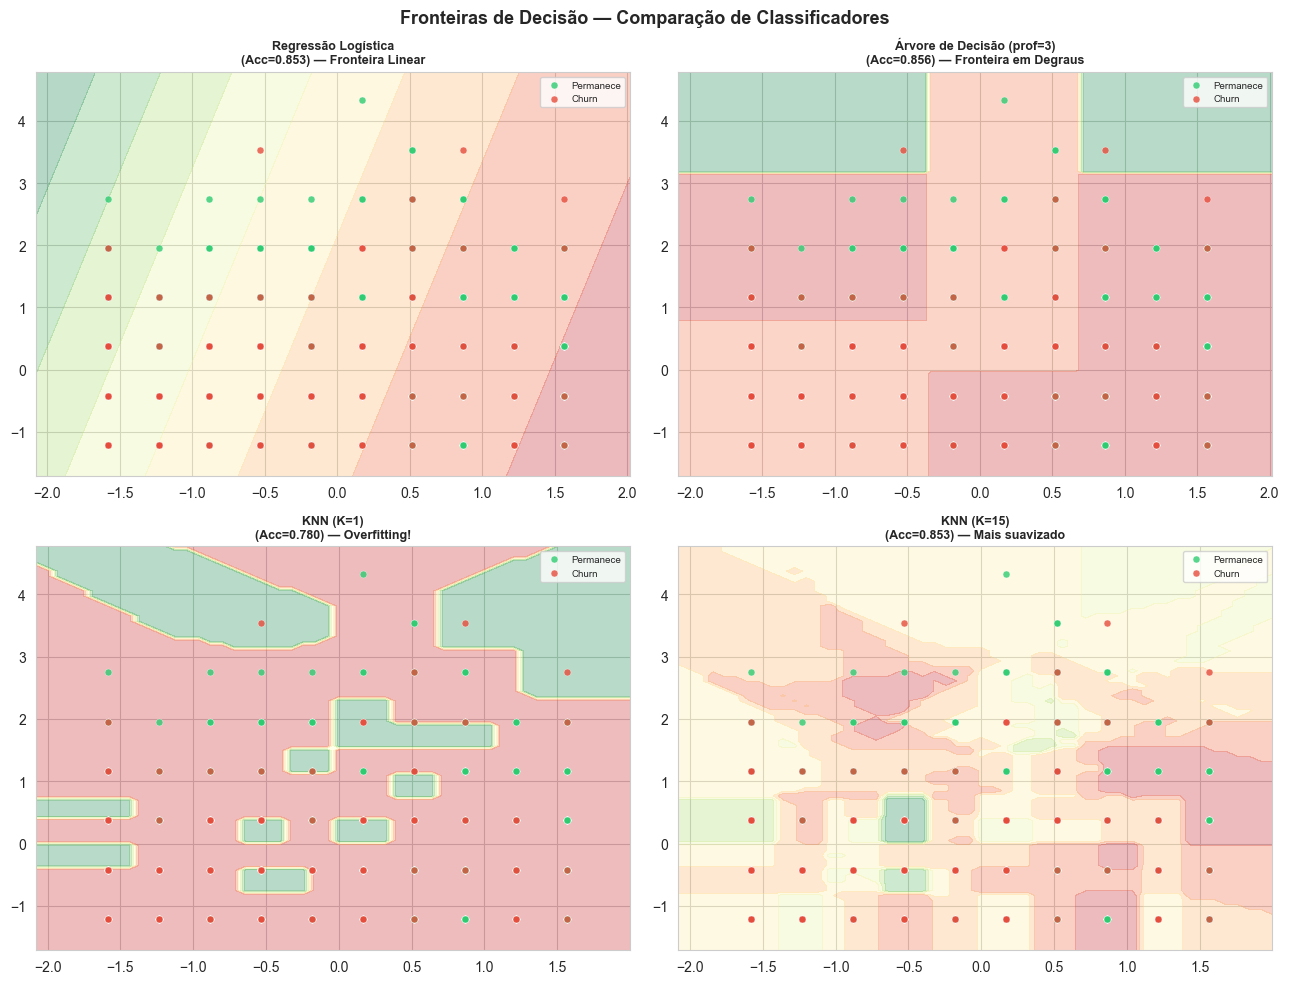

In [2]:
from matplotlib.colors import ListedColormap

def plot_fronteira(modelo, X, y, ax, titulo, h=0.05):
    """Plota fronteira de decisão para 2 features."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    if hasattr(modelo, 'predict_proba'):
        Z = modelo.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='#2ecc71', s=25, alpha=0.8, edgecolors='white', lw=0.3, label='Permanece')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#e74c3c', s=25, alpha=0.8, edgecolors='white', lw=0.3, label='Churn')
    ax.set_title(titulo, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

# Usar apenas 2 features para visualização 2D
X_2d = StandardScaler().fit_transform(X[['satisfacao', 'calls_suporte']])
y_2d = y.values

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Fronteiras de Decisão — Comparação de Classificadores', fontsize=13, fontweight='bold')

# Logistic Regression
lr_2d = LogisticRegression(random_state=42)
lr_2d.fit(X_2d, y_2d)
acc_lr = lr_2d.score(X_2d, y_2d)
plot_fronteira(lr_2d, X_2d, y_2d, axes[0,0], f'Regressão Logística\n(Acc={acc_lr:.3f}) — Fronteira Linear')

# Árvore de Decisão
dt_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_2d.fit(X_2d, y_2d)
acc_dt = dt_2d.score(X_2d, y_2d)
plot_fronteira(dt_2d, X_2d, y_2d, axes[0,1], f'Árvore de Decisão (prof=3)\n(Acc={acc_dt:.3f}) — Fronteira em Degraus')

# KNN k=1 (overfitting)
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_2d, y_2d)
acc_k1 = knn1.score(X_2d, y_2d)
plot_fronteira(knn1, X_2d, y_2d, axes[1,0], f'KNN (K=1)\n(Acc={acc_k1:.3f}) — Overfitting!', h=0.08)

# KNN k=15
knn15 = KNeighborsClassifier(n_neighbors=15)
knn15.fit(X_2d, y_2d)
acc_k15 = knn15.score(X_2d, y_2d)
plot_fronteira(knn15, X_2d, y_2d, axes[1,1], f'KNN (K=15)\n(Acc={acc_k15:.3f}) — Mais suavizado', h=0.08)

plt.tight_layout()
plt.savefig('../imagens/05_fronteiras_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

🌳 ÁRVORE DE DECISÃO — VISUALIZAÇÃO


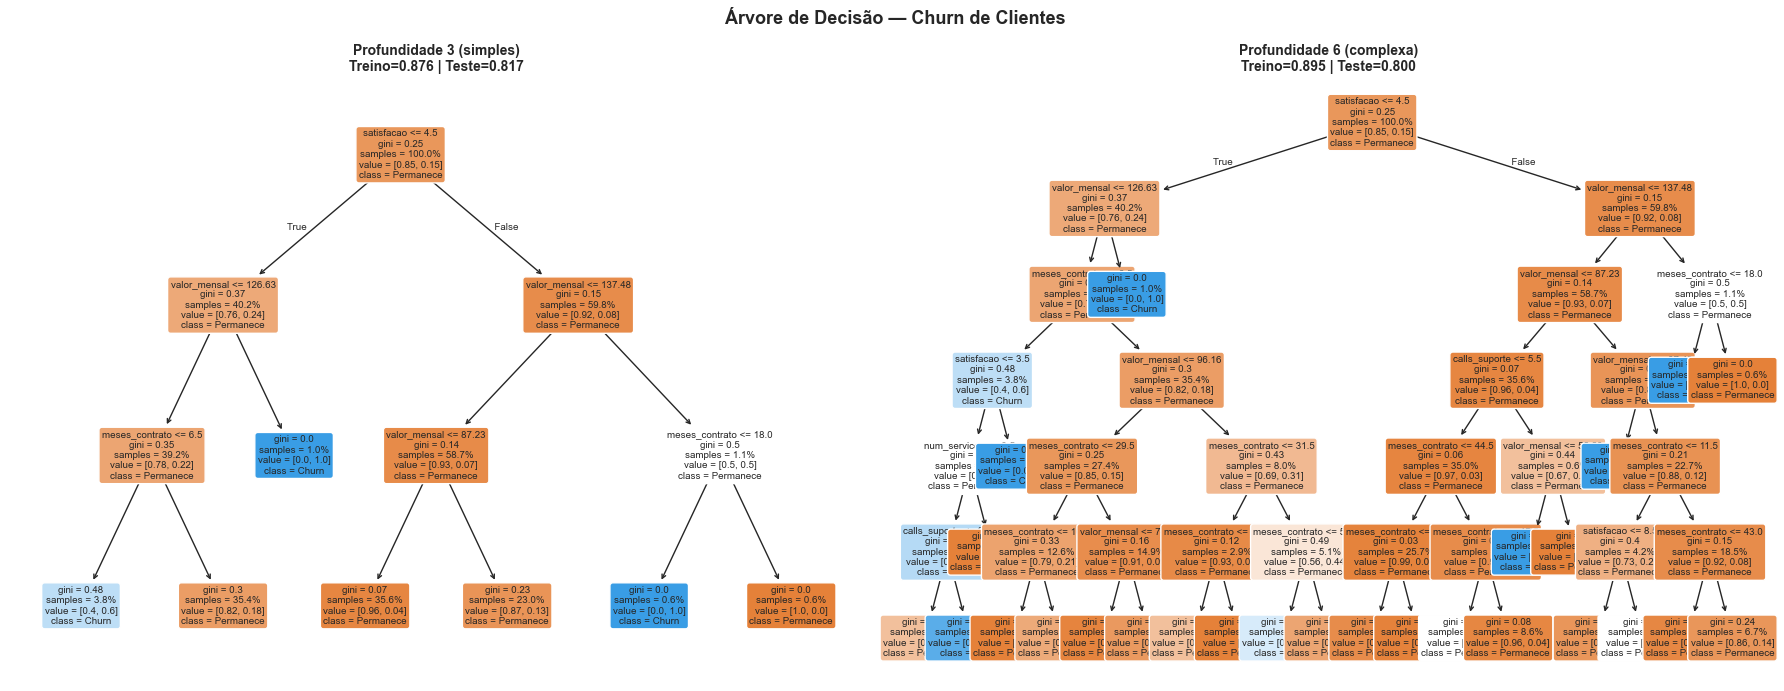


📊 Comparação de K no KNN:


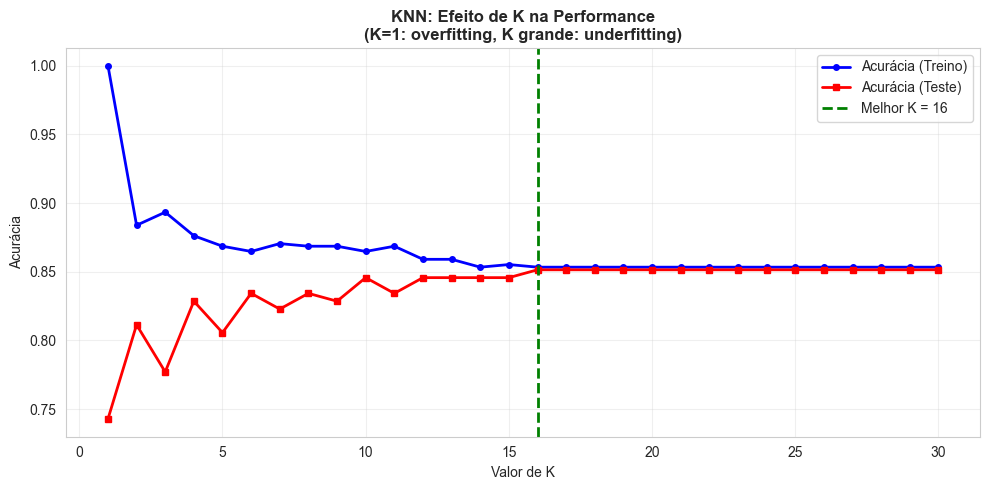


✅ Melhor K = 16 (Acurácia no teste: 0.8514)


In [3]:
print("=" * 55)
print("🌳 ÁRVORE DE DECISÃO — VISUALIZAÇÃO")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Árvore de Decisão — Churn de Clientes', fontsize=13, fontweight='bold')

for ax, profundidade, titulo in zip(axes, [3, 6], ['Profundidade 3 (simples)', 'Profundidade 6 (complexa)']):
    dt = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    dt.fit(X_train, y_train)
    acc_treino = dt.score(X_train, y_train)
    acc_teste = dt.score(X_test, y_test)
    plot_tree(dt, feature_names=X.columns.tolist(), class_names=['Permanece', 'Churn'],
              filled=True, rounded=True, ax=ax, fontsize=7, proportion=True,
              impurity=True, precision=2)
    ax.set_title(f'{titulo}\nTreino={acc_treino:.3f} | Teste={acc_teste:.3f}', 
                  fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../imagens/05_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparação de K para KNN
print("\n📊 Comparação de K no KNN:")
ks = range(1, 31)
acc_treino_knn = []
acc_teste_knn = []
X_train_sc = StandardScaler().fit_transform(X_train)
X_test_sc = StandardScaler().fit_transform(X_test)

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    acc_treino_knn.append(knn.score(X_train_sc, y_train))
    acc_teste_knn.append(knn.score(X_test_sc, y_test))

melhor_k = ks[np.argmax(acc_teste_knn)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, acc_treino_knn, 'b-o', lw=2, ms=4, label='Acurácia (Treino)')
ax.plot(ks, acc_teste_knn, 'r-s', lw=2, ms=4, label='Acurácia (Teste)')
ax.axvline(melhor_k, color='green', lw=2, linestyle='--', label=f'Melhor K = {melhor_k}')
ax.set_xlabel('Valor de K'); ax.set_ylabel('Acurácia')
ax.set_title(f'KNN: Efeito de K na Performance\n(K=1: overfitting, K grande: underfitting)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../imagens/05_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Melhor K = {melhor_k} (Acurácia no teste: {max(acc_teste_knn):.4f})")

🎨 CLASSIFICAÇÃO MULTICLASSE


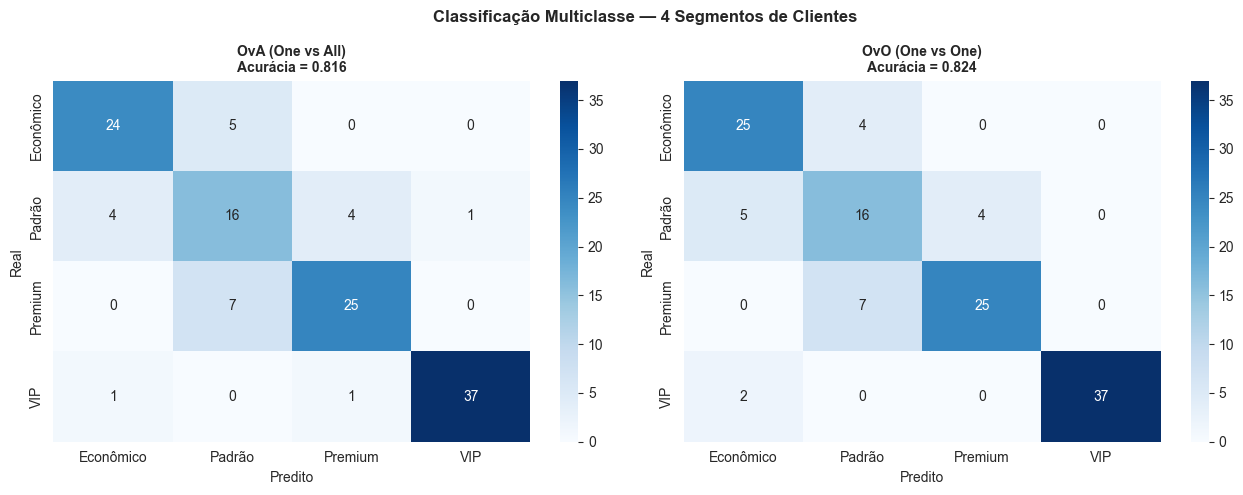


📊 Comparação das Estratégias Multiclasse:


,Acurácia
Logística,0.832
OvO (Logística),0.824
OvA (Logística),0.816
Árvore,0.752


In [4]:
from sklearn.datasets import make_classification

print("=" * 55)
print("🎨 CLASSIFICAÇÃO MULTICLASSE")
print("=" * 55)

# Dataset multiclasse: segmentar clientes em 4 grupos
# n_features >= n_informative + n_redundant
X_mc, y_mc = make_classification(n_samples=500, n_features=6, n_classes=4,
                                   n_informative=4, n_redundant=2, n_clusters_per_class=1,
                                   random_state=42)
nomes_classes = ['Econômico', 'Padrão', 'Premium', 'VIP']

X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(X_mc, y_mc, test_size=0.25, random_state=42)

resultados_mc = {}
for nome, estrategia in [
    ('Logística', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ('OvO (Logística)', OneVsOneClassifier(LogisticRegression(max_iter=1000))),
    ('OvA (Logística)', OneVsRestClassifier(LogisticRegression(max_iter=1000))),
    ('Árvore', DecisionTreeClassifier(max_depth=5, random_state=42)),
]:
    modelo = Pipeline([('sc', StandardScaler()), ('m', estrategia)])
    modelo.fit(X_mc_train, y_mc_train)
    acc = modelo.score(X_mc_test, y_mc_test)
    resultados_mc[nome] = acc

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Classificação Multiclasse — 4 Segmentos de Clientes', fontsize=12, fontweight='bold')

for ax, (nome, estrategia) in zip(axes, [
    ('OvA (One vs All)', OneVsRestClassifier(LogisticRegression(max_iter=1000))),
    ('OvO (One vs One)', OneVsOneClassifier(LogisticRegression(max_iter=1000))),
]):
    modelo = Pipeline([('sc', StandardScaler()), ('m', estrategia)])
    modelo.fit(X_mc_train, y_mc_train)
    y_pred_mc = modelo.predict(X_mc_test)
    cm = confusion_matrix(y_mc_test, y_pred_mc)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=nomes_classes, yticklabels=nomes_classes)
    acc = modelo.score(X_mc_test, y_mc_test)
    ax.set_title(f'{nome}\nAcurácia = {acc:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../imagens/05_multiclasse.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comparação das Estratégias Multiclasse:")
display(pd.DataFrame(resultados_mc, index=['Acurácia']).T.round(4).sort_values('Acurácia', ascending=False))

## 7. Resumo e Exercícios

### 7.1 Comparação dos Classificadores

| Classificador | Fronteira | Interpretabilidade | Escalabilidade | Hiperparâmetros | Principais Prós | Principais Contras |
|---------------|-----------|-------------------|----------------|-----------------|-----------------|--------------------|
| **Regressão Logística** | Linear | Alta (coeficientes + OR) | Excelente | `C` (regularização) | Rápido, probabilístico, interpretável | Só captura relações lineares |
| **Árvore de Decisão** | Em degraus | Alta (regras visuais) | Boa | `max_depth`, `min_samples_split` | Não precisa normalizar, lida com não-linearidade | Overfitting fácil sem poda |
| **KNN** | Irregular | Baixa | Ruim (O(n) na predição) | `n_neighbors` (K), métrica | Simples, sem treinamento | Lento na predição, sensível a outliers e escala |

### 7.2 Quando Usar Cada Algoritmo?

- **Regressão Logística**: quando a relação é aproximadamente linear, há necessidade de probabilidades calibradas ou interpretabilidade regulatória (ex.: crédito, medicina).
- **Árvore de Decisão**: quando se precisa de regras explícitas (ex.: diagnóstico clínico), dados com interações complexas, ou como base para Random Forest/Gradient Boosting.
- **KNN**: protótipos rápidos, datasets pequenos/médios, ou quando a estrutura local dos dados é mais relevante que padrões globais.

---

### 7.3 Exercícios Propostos

**Exercício 1 — Regularização na Regressão Logística**  
Experimente diferentes valores de `C` (ex.: 0.001, 0.01, 0.1, 1, 10, 100) na Regressão Logística.  
- Plote a curva de AUC-ROC (treino vs. teste) em função de `C`.  
- Qual valor de `C` evita overfitting e mantém boa generalização?  
- Como os coeficientes mudam com `C` muito pequeno vs. muito grande?

**Exercício 2 — Poda de Árvore de Decisão**  
Treine Árvores de Decisão com `max_depth` variando de 1 a 15.  
- Plote a acurácia de treino e teste em função da profundidade.  
- Identifique o ponto de "codo" onde ocorre overfitting.  
- Compare a importância de features para `max_depth=3` vs. `max_depth=10`.

**Exercício 3 — Pipeline Completo com Avaliação**  
Monte um pipeline de comparação automática entre LR, Árvore e KNN usando `cross_val_score` (5-fold) no dataset de churn.  
- Reporte média e desvio padrão de acurácia, F1-score e AUC-ROC para cada modelo.  
- Use `GridSearchCV` para otimizar o hiperparâmetro principal de cada classificador.  
- Qual modelo apresenta melhor equilíbrio entre performance e estabilidade entre os folds?